In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm
from numpy.linalg import eigvalsh
from tqdm import trange, tqdm
from math import isfinite

# Default plotting style (optional)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.35,
})


# Default RNG
GLOBAL_SEED = 7
rng = np.random.default_rng(GLOBAL_SEED)

### Overview

This code explores how **graph structure** and **controllability properties** evolve across different edge densities in connected Erdős–Rényi (ER) graphs.

For each edge probability $ p $, it:

1. Generates **two connected ER graphs** $ G_1(n,p) $ and $ G_2(n,p) $.
2. Converts them into a chosen **matrix representation** (Adjacency, Laplacian, Signless Laplacian, or Normalized Laplacian).
3. Computes **spectral distances** (differences in eigenvalues) between graph matrices.
4. Constructs **finite-time controllability Gramians** using a block matrix exponential method.
5. Compares controllability metrics such as:
   - Trace difference
   - Spectral distance between Gramians
   - Log-determinant difference
6. Produces plots showing how these measures vary with edge density $ p $.

---

### Key Components

#### 1. Graph Sampling
`connected_erdos_renyi(n, p, rng, max_attempts)`  
Generates a connected Erdős–Rényi graph $ G(n, p) $, resampling until a connected instance is found.

#### 2. Matrix Representations
You can choose one of several structural matrices:
| Name | Symbol | Definition |
|------|---------|------------|
| Adjacency | $ A $ | Standard edge connectivity matrix |
| Laplacian | $ L = D - A $ | Captures diffusion or flow structure |
| Signless Laplacian | $ Q = D + A $ | Encodes degree–adjacency interactions |
| Normalized Laplacian | $ L_{\text{norm}} = I - D^{-1/2} A D^{-1/2} $ | Scale-invariant Laplacian used in clustering |

#### 3. Spectral Distance
`spectral_distance(G1, G2, matrix_fn, ord_norm)`  
Computes the distance between the sorted eigenvalue spectra of two matrices:

$$
d(G_1, G_2) = \|\lambda(M(G_1)) - \lambda(M(G_2))\|_k,
$$

where $ k $ can be 1, 2, or ∞.

#### 4. Finite-Time Controllability Gramian
`finite_time_gramian(A, B, t)`  
Computes the **finite-time controllability Gramian**:

$$
W_t = \int_0^t e^{A\tau} B B^\top e^{A^\top \tau} \, d\tau,
$$

using Van Loan’s block-exponential formulation (1978).

This provides an exact solution without numerical integration.

#### 5. Determinant Utilities
- `safe_det_psd(W)`: Returns the determinant if the matrix is full rank.  
- `logdet_psd(W)`: Computes a stable log-determinant for nearly singular or PSD matrices.

---

### Two Experiments

#### **1. Spectral Experiment**
- Samples pairs of connected graphs.
- Computes mean and standard deviation of spectral distances over different $ p $.
- Plots **average spectral distance vs. edge density**.

#### **2. Gramian Experiment**
- Uses the same matrix representation for $ A $.
- Builds Gramians $ W_t $ and compares:
  - **Spectral distance of A**
  - **Trace difference of Wₜ**
  - **Spectral distance between Wₜ eigenvalues**
  - **Log-det difference** (robust to rank deficiency)

---

### Outputs and Interpretation

**Plots produced:**
1. **Spectral Distance vs. Trace Difference** — relationship between graph structure and controllability energy.
2. **Gramian Spectral Distance vs. Edge Density** — how controllability spectra evolve as graphs densify.
3. **Log-Det Difference vs. Edge Density** — stability of controllability volume across densities.

**Insights:**
- Sparse graphs (small $ p $) show large variability in both structure and controllability.
- As $ p $ increases, graphs become more similar and controllability measures converge.
- The log-determinant metric is stable even when Gramians are near-singular.

---

### Configuration Notes

- **`matrix_choice`** → Select `"adjacency"`, `"laplacian"`, `"signless_laplacian"`, or `"normalized_laplacian"`.
- **`B_type`** → `"ones"` for rank-1 input, `"identity"` for full actuation (SPD Gramians).
- **`t_horizon`** → Controls how long input effects are integrated.
- **`max_attempts`** → Increase if graphs near the connectivity threshold fail to appear.
- **`n`** and **`p_values`** → Control graph size and density range.

---

### Citation

Van Loan, C. F. (1978). *“Computing Integrals Involving the Matrix Exponential.”*  
IEEE Transactions on Automatic Control, 23(3), 395–404.


### Finite-Time Controllability Gramian

The function `finite_time_gramian(A, B, t)` computes the **finite-time controllability Gramian** $W_t$ for a continuous-time linear time-invariant (LTI) system:

$$
\dot{x}(t) = A x(t) + B u(t),
$$

The finite-time controllability Gramian is defined as:

$$
W_t = \int_0^t e^{A \tau} B B^\top e^{A^\top \tau} \, d\tau,
$$

which quantifies how the control input $u(t)$ influences the system states $x(t)$ over a finite time horizon $t$.  
For controllable systems, $W_t$ is **positive definite** for any $t > 0$.

---

#### Numerical Computation via the Matrix Exponential

Instead of numerical integration, $W_t$ can be computed **exactly** using a block matrix exponential.  
Define the augmented matrix:

$$
M =
\begin{bmatrix}
 -A & B B^\top \\
  0 & A^\top
\end{bmatrix}.
$$

Then:

$$
\exp(M t) =
\begin{bmatrix}
 \Phi_{11}(t) & \Phi_{12}(t) \\
  0 & \Phi_{22}(t)
\end{bmatrix},
$$

and the finite-time controllability Gramian is given by:

$$
W_t = \Phi_{22}(t)^\top \Phi_{12}(t).
$$

This formulation follows the **Van Loan method** for computing matrix-exponential integrals and is implemented in Python using `scipy.linalg.expm`.

---

#### Implementation Notes

- The function constructs the block matrix $M$ and evaluates $\exp(Mt)$.  
- The variable `t` represents the **finite time horizon**.  
- This Python version is equivalent to the MATLAB code:
  ```matlab
  temp = expm([-A B*B'; zeros(n,n) A'] * t);
  Wt = temp(n+1:2*n, n+1:2*n)' * temp(1:n, n+1:2*n);


In [2]:
def finite_Gramian(A, B):
    """
    Compute the finite controllability Gramian using the matrix exponential method.
        Wt = finite_Gramian(A, B)
    """

    n = A.shape[0]
    D = 1  # Time scaling factor

    # Construct the block matrix
    top = np.hstack([-A.T, B @ B.T])
    bottom = np.hstack([np.zeros((n, n)), A])
    M = np.vstack([top, bottom])

    # Compute the matrix exponential
    temp = expm(M * D)

    # Extract the submatrices
    Wt = temp[n:2*n, n:2*n].T @ temp[0:n, n:2*n]

    return Wt

In [11]:
# ---------- ER: connected sampler ----------
def connected_erdos_renyi(n, p, rng, max_attempts=200):
    """Sample a connected G(n,p)."""
    for _ in range(max_attempts):
        G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))
        if nx.is_connected(G):
            return G
    raise RuntimeError(f"Could not sample a connected G(n,{p:.3f}) after {max_attempts} tries.")

# ---------- Matrix builders ----------
def A_matrix(G):
    """Adjacency matrix."""
    return nx.to_numpy_array(G, dtype=np.float64)

def L_matrix(G):
    """Combinatorial Laplacian L = D - A."""
    A = A_matrix(G)
    D = np.diag(A.sum(axis=1))
    return D - A

def Q_matrix(G):
    """Signless Laplacian Q = D + A."""
    A = A_matrix(G)
    D = np.diag(A.sum(axis=1))
    return D + A

def L_norm_matrix(G):
    """Normalized Laplacian L_sym = I - D^{-1/2} A D^{-1/2}."""
    A = A_matrix(G)
    deg = A.sum(axis=1)
    inv_sqrt = 1.0 / np.sqrt(deg)
    S = np.diag(inv_sqrt)
    I = np.eye(A.shape[0])
    return I - S @ A @ S

MATRIX_FNS = {
    "adjacency": A_matrix,
    "laplacian": L_matrix,
    "signless_laplacian": Q_matrix,
    "normalized_laplacian": L_norm_matrix,
}

# ---------- Spectral distance (reusable) ----------
def spectral_distance(G1, G2, matrix_fn, ord_norm=1):
    """
    || lambda(M(G1)) - lambda(M(G2)) ||_{ord_norm},
    where M is symmetric (A, L, Q, L_norm) and eigenvalues are sorted.
    """
    M1 = matrix_fn(G1)
    M2 = matrix_fn(G2)
    lam1 = eigvalsh(M1)
    lam2 = eigvalsh(M2)
    return np.linalg.norm(np.sort(lam1) - np.sort(lam2), ord=ord_norm)

# ---------- Generic plotting ----------
def plot_mean_std(p_values, means, stds, *, title=None, ylabel=None, show_band=True, marker="o"):
    plt.figure(figsize=(7.6, 5.0))
    plt.plot(p_values, means, marker=marker, linewidth=2, label='Mean')
    if show_band:
        plt.fill_between(p_values, means - stds, means + stds, alpha=0.2, label='±1 std')
    plt.xlabel('Edge density p')
    plt.ylabel(ylabel or 'Spectral distance')
    plt.title(title or 'Distance vs p')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_scatter(x, y, *, title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=(7.2, 4.6))
    plt.scatter(x, y, s=24, alpha=0.7)
    plt.xlabel(xlabel or "x")
    plt.ylabel(ylabel or "y")
    plt.title(title or "")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



def finite_time_gramian(A, B, t=1.0):
    """
    Compute the finite-time controllability Gramian

        W_t = ∫_0^t e^{A τ} B B^T e^{A^T τ} dτ

    using the Van Loan block-matrix exponential identity.

    Parameters
    ----------
    A : (n, n) ndarray
        System / graph matrix (e.g., adjacency, Laplacian, etc.).
    B : (n, m) ndarray
        Input matrix.
    t : float
        Time horizon.

    Returns
    -------
    W_t : (n, n) ndarray
        Finite-time controllability Gramian.
    """
    n = A.shape[0]
    top = np.hstack([-A, B @ B.T])
    bot = np.hstack([np.zeros((n, n)), A.T])
    M = np.vstack([top, bot])
    T = expm(M * t)
    F22 = T[n:2*n, n:2*n]
    F12 = T[0:n,   n:2*n]
    return F22.T @ F12  # symmetric PSD

def safe_det_psd(W, tol=1e-12):
    ev = eigvalsh(W)
    full = np.min(ev) > tol
    return (float(np.prod(ev)) if full else 0.0), full

def logdet_psd(W, tol=1e-12):
    ev = eigvalsh(W)
    kept = ev[ev > tol]
    if kept.size == 0:
        return -np.inf, 0, False
    return float(np.sum(np.log(kept))), kept.size, (kept.size == ev.size)


In [4]:
def run_spectral_experiment(
    n=300,
    p_values=None,
    trials_per_p=8,
    max_tries=1000,
    base_seed=123,
    matrix_choice="adjacency",
    ord_norm=1,
    show_progress=True,
):
    """
    Returns: p_values, means, stds using shared utilities.
    """
    if p_values is None:
        p_values = np.linspace(5/n, 0.9, 18)

    rng = np.random.default_rng(base_seed)
    matrix_fn = MATRIX_FNS[matrix_choice]
    means, stds = [], []

    iterator = tqdm(p_values) if show_progress else p_values
    for p in iterator:
        dists = []
        for _ in range(trials_per_p):
            seed1 = int(rng.integers(0, 2**32 - 1))
            seed2 = int(rng.integers(0, 2**32 - 1))
            rg1 = np.random.default_rng(seed1)
            rg2 = np.random.default_rng(seed2)

            G1 = connected_erdos_renyi(n, p, rg1, max_attempts=max_tries)
            G2 = connected_erdos_renyi(n, p, rg2, max_attempts=max_tries)

            dists.append(spectral_distance(G1, G2, matrix_fn, ord_norm=ord_norm))

        means.append(np.mean(dists))
        stds.append(np.std(dists, ddof=1) if len(dists) > 1 else 0.0)

    return np.array(p_values), np.array(means), np.array(stds)


In [5]:
def run_gramian_experiment(
    n=12,
    p_values=None,
    trials=6,
    t_horizon=1.0,
    matrix_choice="adjacency",  # reuse MATRIX_FNS
    B_type="ones",              # 'ones' (rank-1) or 'identity' (full actuation)
    max_attempts=300,
    tol_rank=1e-10,
    base_seed=7,
    show_progress=True,
):
    """
    Returns a dict with scatter data, per-p aggregates, and params, reusing common utilities.
    """
    if p_values is None:
        p_values = np.linspace(0.2, 0.95, 15)

    rng = np.random.default_rng(base_seed)
    matrix_fn = MATRIX_FNS[matrix_choice]

    # Input matrix
    if B_type == "ones":
        B = np.ones((n, 1))
    elif B_type == "identity":
        B = np.eye(n)
    else:
        raise ValueError("B_type must be 'ones' or 'identity'")

    # Collectors
    xs, ys, ps = [], [], []
    gram_spectral_by_p = [[] for _ in range(len(p_values))]
    logdet_diff_by_p   = [[] for _ in range(len(p_values))]
    det_diff_by_p      = [[] for _ in range(len(p_values))]

    iterator = enumerate(p_values)
    if show_progress:
        iterator = enumerate(tqdm(p_values))

    for ip, p in iterator:
        for _ in range(trials):
            seed1 = int(rng.integers(0, 2**32 - 1))
            seed2 = int(rng.integers(0, 2**32 - 1))
            rg1 = np.random.default_rng(seed1)
            rg2 = np.random.default_rng(seed2)

            G1 = connected_erdos_renyi(n, p, rg1, max_attempts=max_attempts)
            G2 = connected_erdos_renyi(n, p, rg2, max_attempts=max_attempts)

            # Use the same matrix builder as spectral experiment
            A1 = matrix_fn(G1)
            A2 = matrix_fn(G2)

            # X: spectral distance of chosen matrix
            d_spec = np.linalg.norm(eigvalsh(A1) - eigvalsh(A2), ord=2)

            # Finite-time Gramians
            W1 = finite_time_gramian(A1, B, t=t_horizon)
            W2 = finite_time_gramian(A2, B, t=t_horizon)

            # Y: |trace difference|
            tr_diff = abs(np.trace(W1) - np.trace(W2))
            if isfinite(d_spec) and isfinite(tr_diff):
                xs.append(d_spec)
                ys.append(tr_diff)
                ps.append(p)

            # Gramian spectral distance
            d_gram = np.linalg.norm(eigvalsh(W1) - eigvalsh(W2), ord=2)
            if isfinite(d_gram):
                gram_spectral_by_p[ip].append(d_gram)

            # Determinant & log-det differences
            det1, ok1 = safe_det_psd(W1, tol=tol_rank)
            det2, ok2 = safe_det_psd(W2, tol=tol_rank)
            if ok1 and ok2:
                det_diff_by_p[ip].append(abs(det1 - det2))

            ld1, _, _ = logdet_psd(W1, tol=tol_rank)
            ld2, _, _ = logdet_psd(W2, tol=tol_rank)
            if np.isfinite(ld1) and np.isfinite(ld2):
                logdet_diff_by_p[ip].append(abs(ld1 - ld2))

    return {
        "xs": xs, "ys": ys, "ps": ps,
        "gram_spectral_by_p": gram_spectral_by_p,
        "logdet_diff_by_p": logdet_diff_by_p,
        "det_diff_by_p": det_diff_by_p,
        "p_values": np.array(p_values),
        "params": dict(n=n, t_horizon=t_horizon, matrix_choice=matrix_choice, B_type=B_type)
    }



def plot_trace_vs_spectral(results):
    xs, ys = results["xs"], results["ys"]
    n = results["params"]["n"]
    t_h = results["params"]["t_horizon"]
    mt = results["params"]["matrix_choice"]
    plot_scatter(
        xs, ys,
        title=f"{mt.replace('_',' ').title()} spectral distance vs Gramian trace difference\nG(n={n}), t={t_h}",
        xlabel=f"Spectral distance of {mt} (L2 of eigenvalues)",
        ylabel=r"$|\mathrm{tr}(W_t^{(1)}) - \mathrm{tr}(W_t^{(2)})|$",
    )

def plot_mean_band_from_lists(p_values, lists_by_p, *, ylabel, title, marker="o"):
    means, stds = [], []
    for lst in lists_by_p:
        if len(lst) > 0:
            means.append(np.mean(lst))
            stds.append(np.std(lst, ddof=1) if len(lst) > 1 else 0.0)
        else:
            means.append(np.nan); stds.append(np.nan)
    means, stds = np.array(means), np.array(stds)
    plot_mean_std(p_values, means, stds, title=title, ylabel=ylabel, show_band=True, marker=marker)



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 13.64it/s]


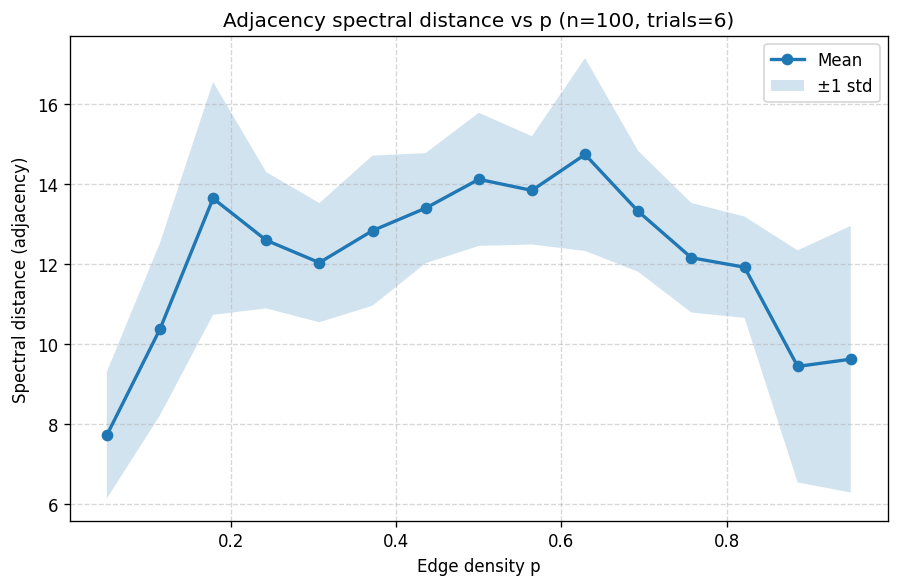

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [01:35<00:00,  6.37s/it]


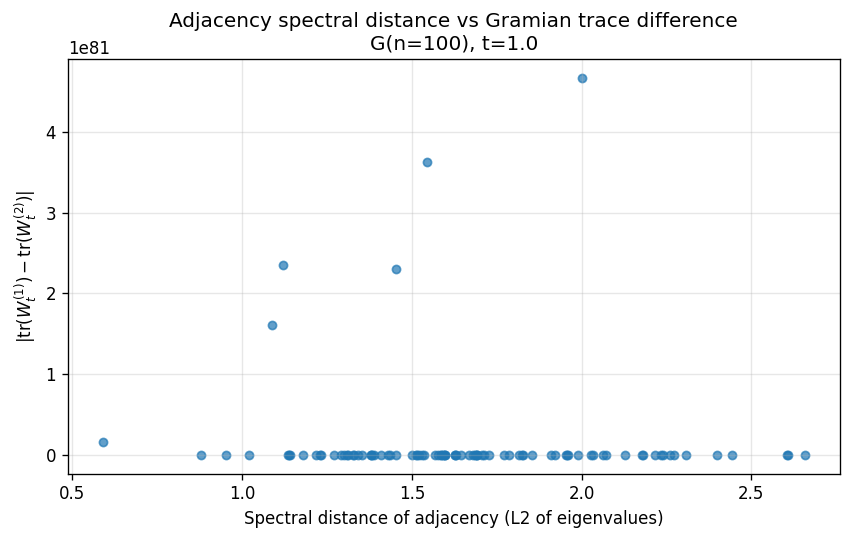

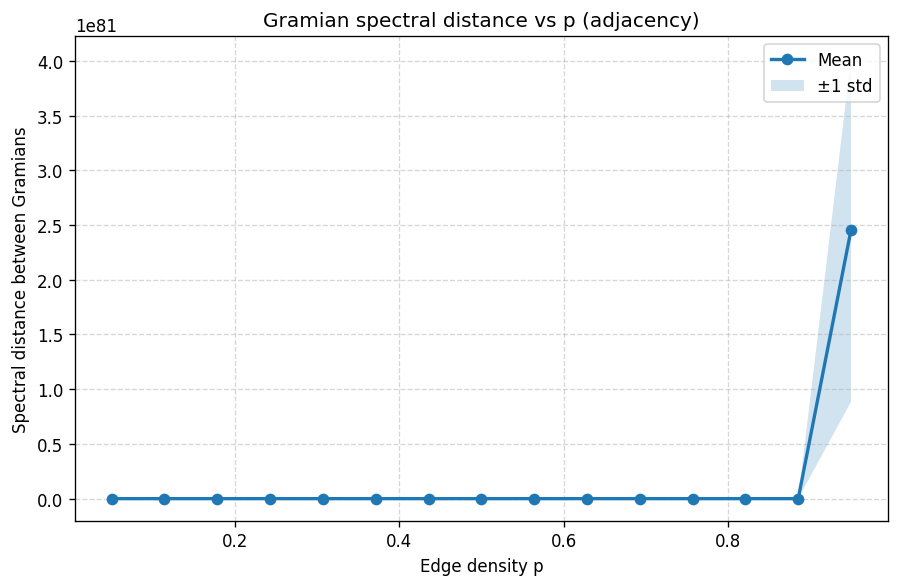

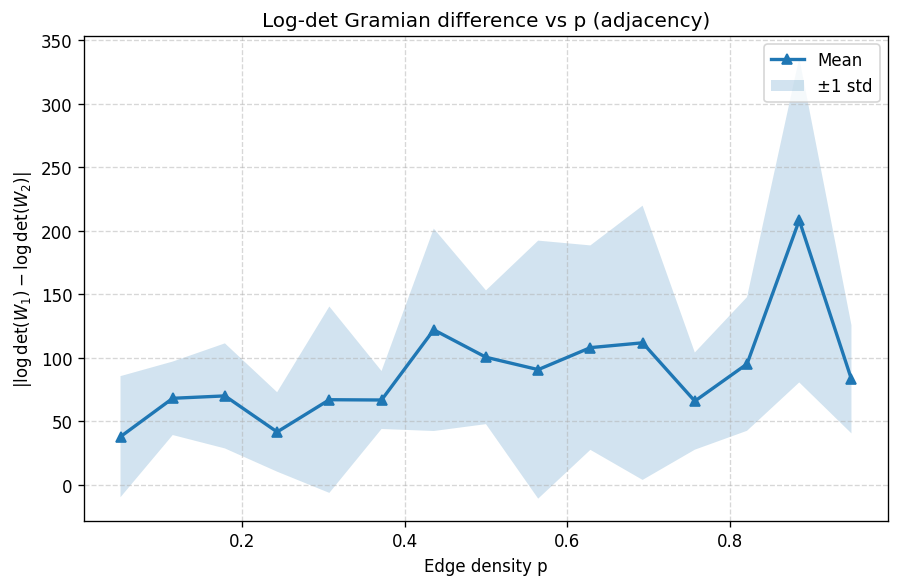

In [ ]:
# Common parameters
n = 100
p_values = np.linspace(5/n, 0.95, 15)
trials = 6
matrix_choice = "adjacency"     # adjacency | laplacian | signless_laplacian | normalized_laplacian

# ----- Spectral experiment (reuses connected_erdos_renyi, MATRIX_FNS, spectral_distance, plot_mean_std) -----
p_vals, means, stds = run_spectral_experiment(
    n=n,
    p_values=p_values,
    trials_per_p=trials,
    max_tries=1000,
    base_seed=123,
    matrix_choice=matrix_choice,
    ord_norm=1,
    show_progress=True
)
plot_mean_std(
    p_vals, means, stds,
    title=f"{matrix_choice.replace('_',' ').title()} spectral distance vs p (n={n}, trials={trials})",
    ylabel=f"Spectral distance ({matrix_choice.replace('_',' ')})",
    show_band=True,
)

# ----- Gramian experiment (reuses same matrix_choice and plotting utilities) -----
results = run_gramian_experiment(
    n=n, 
    p_values=p_values,
    trials=trials,
    t_horizon=1.0,
    matrix_choice=matrix_choice,  # SAME registry & builders reused
    B_type="ones",                # or 'identity' for guaranteed SPD W_t
    max_attempts=1000,
    tol_rank=1e-10,
    base_seed=7,
    show_progress=True
)

# scatter: spectral distance of chosen matrix vs |trace difference|
plot_trace_vs_spectral(results)

# mean ± std: Gramian spectral distance vs p
plot_mean_band_from_lists(
    results["p_values"], results["gram_spectral_by_p"],
    ylabel="Spectral distance between Gramians",
    title=f"Gramian spectral distance vs p ({matrix_choice})",
    marker="o"
)

# mean ± std: log-det difference vs p (robust even if W_t is rank-deficient)
plot_mean_band_from_lists(
    results["p_values"], results["logdet_diff_by_p"],
    ylabel=r"$|\log\det(W_1) - \log\det(W_2)|$",
    title=f"Log-det Gramian difference vs p ({matrix_choice})",
    marker="^"
)


### Edge Influence Scores via Energy-Transfer Edge Centrality

This code implements an **edge influence (energy-based edge centrality)** method inspired by  
*“Energy-Transfer Edge Centrality and Its Role in Enhancing Network Controllability”*  
by Chanekar, Nozari, and Cortés.

The core idea is that an edge’s importance in a networked dynamical system can be measured by how much it contributes to the **energy flow** or **controllability** of the system.  
Edges that significantly change controllability energy (as measured via the controllability Gramian) are deemed **highly influential**.

---

### 1. System and Gramian

For a continuous-time linear network system
$$
\dot{x}(t) = A x(t) + B u(t),
$$

the **finite-time controllability Gramian** is

$$
W_t = \int_0^t e^{A \tau} B B^\top e^{A^\top \tau} \, d\tau.
$$

It captures how input energy propagates through the network over a finite horizon $t$.  
A larger $\mathrm{trace}(W_t)$ corresponds to greater controllability energy (i.e., easier state reachability).

In the code, $W_t$ is computed using **Van Loan’s block matrix exponential method**, which avoids explicit numerical integration.

---

### 2. Modular Graph Matrices

The system matrix $ A $ is built from the graph using a **modular matrix interface**.  
You can choose the representation via the string `matrix_choice`:

- `"adjacency"`: adjacency matrix $ A $  
- `"laplacian"`: combinatorial Laplacian $ L = D - A $  
- `"signless_laplacian"`: signless Laplacian $ Q = D + A $  
- `"normalized_laplacian"`: normalized Laplacian $ L_{\text{norm}} = I - D^{-1/2} A D^{-1/2} $

This allows you to study edge influence not just at the adjacency level, but also in diffusion-like or Laplacian-based views of the network.

---

### 3. Energy-Based Edge Scores (All Pairs)

The code computes an **energy-transfer score** for **every unordered node pair** $ (u, v) $, whether or not it is an edge in the original graph:

- Let $ W_t^{\text{full}} $ be the Gramian for the original graph $ G $ and matrix $ A $ (for the chosen `matrix_choice`).
- For each pair $ (u, v) $:

  - If $ (u, v) $ **is an edge** in the original graph:

    $$
    \text{score}(u, v) = \mathrm{tr}(W_t^{\text{full}}) - \mathrm{tr}(W_t^{(-e)}),
    $$
    where $ W_t^{(-e)} $ is the Gramian after **removing** edge $ e = (u, v) $.

  - If $ (u, v) $ is **not an edge** in the original graph:
    
    $$
    \text{score}(u, v) = \mathrm{tr}(W_t^{\text{full}}) - \mathrm{tr}(W_t^{(+e)}),
    $$

    where $ W_t^{(+e)} $ is the Gramian after **adding** edge $ e = (u, v) $.

Interpretation:

- For **existing edges**, a large positive score means removing that edge causes a big drop in controllability energy → the edge is important.
- For **non-edges**, a large negative score means adding that edge would **increase** controllability energy → the edge is a promising candidate to add.

This provides an **energy-transfer interpretation** of both existing and potential edges.

---

### 4. Edge Operations: Remove, Add, Substitute

Using these scores, the code can perform three types of experiments, controlled by `mode`:

1. **Remove** (`mode="remove"`):  
   - Rank existing edges by **decreasing score** (largest trace drop first).  
   - Iteratively **remove** edges in this order.  
   - After each removal, record:
     - $\mathrm{trace}(W_t)$ for the chosen matrix,
     - the **spectral distance** between the current matrix $ A_{\text{curr}} $ and the original matrix $ A_0 $.

2. **Add** (`mode="add"`):  
   - Consider all **non-edges** and rank them by **ascending score** (most negative first → biggest improvement).  
   - Iteratively **add** edges in this order.  
   - After each addition, again record trace(Wₜ) and spectral distance.

3. **Substitute** (`mode="substitute"`):  
   - Pair up:
     - a **minimum-score existing edge** to remove, and  
     - a **minimum-score non-edge** to add.  
   - At each step, **remove** the low-score existing edge and **add** the low-score non-edge.  
   - This keeps the number of edges roughly constant while reshaping the network according to the energy-based criteria.

In all modes, the **graph matrix** is always rebuilt with the selected `matrix_choice`, and the Gramian is recomputed using that matrix.

---

### 5. Spectral Distance and Plots

For each step of the experiment, in addition to $\mathrm{trace}(W_t)$, the code computes the **spectral distance** between the current and original graph matrices:

$$
d_{\text{spec}} = \left\| \lambda(A_0) - \lambda(A_{\text{curr}}) \right\|_2,
$$

where $ \lambda(\cdot) $ denotes the vector of sorted eigenvalues.

The plotting routine shows:

1. A **combined plot** with:
   - Normalized trace $ \mathrm{trace}(W_t) / \mathrm{trace}(W_t)_0 $ on the left y-axis.
   - Spectral distance $ d_{\text{spec}} $ on the right y-axis.
   - x-axis: fraction of edge operations (removals, additions, or substitutions).

2. A **separate spectral-distance-only plot**, to isolate changes in matrix spectrum.

These plots provide a dual view:
- How controllability energy evolves as edges are manipulated.
- How far the chosen graph matrix drifts away from its original spectrum.

---

### 6. Interpretation

- **High-score existing edges** (for removal):
  - Strongly support network controllability.
  - Their removal causes a large drop in trace(Wₜ) and often a noticeable spectral change.

- **Strongly negative-score non-edges** (for addition):
  - Are excellent candidates to **boost** controllability when added.
  - Reflect edges along which energy transfer is particularly beneficial.

- **Substitution mode** highlights trade-offs:
  - You can redesign the network structure by removing less critical edges and adding more beneficial ones, while keeping edge count similar.
  - Observing how trace(Wₜ) and spectra change under substitutions reveals how controllability can be enhanced without heavily changing overall sparsity.

---

### 7. Extensions and Choices

- **Matrix choice:**  
  By toggling `matrix_choice` between `"adjacency"`, `"laplacian"`, `"signless_laplacian"`, and `"normalized_laplacian"`, you can study edge influence in:
  - raw connectivity (adjacency),
  - diffusion/flow structure (Laplacian),
  - degree–adjacency interactions (signless Laplacian),
  - or normalized, scale-invariant form (normalized Laplacian).

- **Input matrix $ B $:**
  - `B = np.ones((n, 1))` → rank-1, uniform input at all nodes.  
  - `B = np.eye(n)` → full actuation, which guarantees positive definite Gramians for connected graphs and simplifies determinant-based metrics.

- **Real networks:**  
  Replace the Erdős–Rényi graph with any real-world `networkx` graph to identify edges that matter most (or potential edges to add) from a controllability viewpoint.

---

### 8. Reference

Chanekar, M., Nozari, E., & Cortés, J. (2022).  
*“Energy-Transfer Edge Centrality and Its Role in Enhancing Network Controllability.”*


Removing edges (adjacency): 100%|██████████| 115/115 [00:00<00:00, 1087.29it/s]


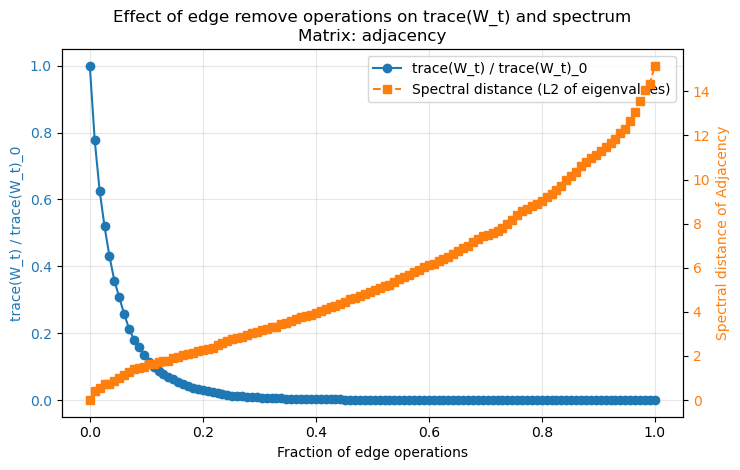

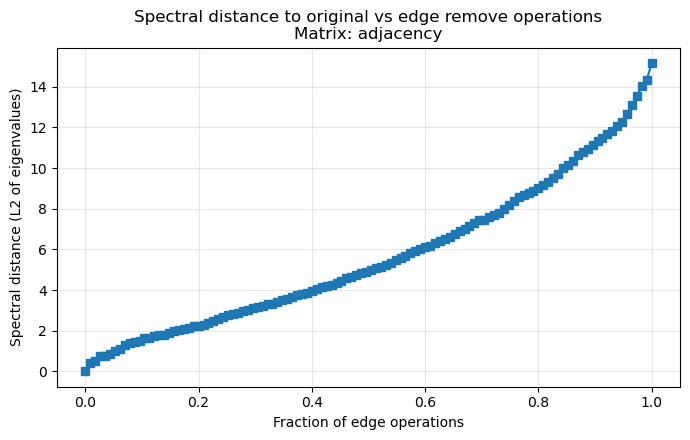

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm, eigvalsh
from tqdm import tqdm


# -----------------------------
# Finite-time Gramian
# -----------------------------
def finite_time_gramian(A, B, t=1.0):
    """
    W_t = ∫_0^t e^{A τ} B B^T e^{A^T τ} dτ
    via Van Loan block exponential.
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    B = np.asarray(B, dtype=float)

    top = np.hstack([-A, B @ B.T])
    bot = np.hstack([np.zeros((n, n)), A.T])
    M = np.vstack([top, bot])
    T = expm(M * t)
    F22 = T[n:2*n, n:2*n]
    F12 = T[0:n,   n:2*n]
    return F22.T @ F12


# -----------------------------
# Spectral distance between symmetric matrices
# -----------------------------
def spectral_distance_eigs_l2(A, B):
    """
    L2 distance between sorted eigenvalues of two symmetric matrices A, B.
    """
    evA = eigvalsh(A)
    evB = eigvalsh(B)
    return np.linalg.norm(evA - evB, ord=2)


# -----------------------------
# Modular graph matrix functions
# -----------------------------
def adjacency_matrix_np(G, node_list):
    """Adjacency matrix A."""
    return nx.to_numpy_array(G, nodelist=node_list, dtype=float)


def laplacian_matrix_np(G, node_list):
    """Combinatorial Laplacian L = D - A."""
    return nx.laplacian_matrix(G, nodelist=node_list).astype(float).toarray()


def signless_laplacian_matrix_np(G, node_list):
    """Signless Laplacian Q = D + A."""
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    D = np.diag(d)
    return D + A


def normalized_laplacian_matrix_np(G, node_list):
    """
    Compute the normalized Laplacian matrix:
        L_norm = I - D^{-1/2} A D^{-1/2}
    Works without using scipy.errstate (avoids compatibility issues).
    """
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    with np.errstate(divide='ignore'):
        d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    I = np.eye(len(node_list))
    L_norm = I - D_inv_sqrt @ A @ D_inv_sqrt
    return L_norm

# Registry of matrix functions
MATRIX_FNS = {
    "adjacency": adjacency_matrix_np,
    "laplacian": laplacian_matrix_np,
    "signless_laplacian": signless_laplacian_matrix_np,
    "normalized_laplacian": normalized_laplacian_matrix_np,
}


def get_matrix_fn(matrix_choice):
    """
    Get the matrix builder function from MATRIX_FNS.
    """
    key = matrix_choice.lower()
    if key not in MATRIX_FNS:
        raise ValueError(
            f"Unknown matrix_choice '{matrix_choice}'. "
            f"Use one of: {list(MATRIX_FNS.keys())}"
        )
    return MATRIX_FNS[key]


# -----------------------------
# Energy-based scores for ALL possible edges (pairs)
# -----------------------------
def edge_energy_scores_all_pairs(G, B, t_horizon=1.0, matrix_choice="adjacency"):
    """
    Compute an energy-based score for every unordered pair (u, v), u < v.

    Relative to the ORIGINAL graph G and its Gramian trace tr(W_full):

    - If (u, v) is an edge in G:
        score(u, v) = tr(W_full) - tr(W_without_edge)

    - If (u, v) is NOT an edge in G:
        score(u, v) = tr(W_full) - tr(W_with_edge_added)

    When adding an edge increases trace, that score is negative.

    Parameters
    ----------
    G : networkx.Graph
    B : (n, m) ndarray
    t_horizon : float
    matrix_choice : str
        One of: "adjacency", "laplacian", "signless_laplacian", "normalized_laplacian"

    Returns
    -------
    scores: dict
        (u, v) with u < v -> float score
    A_full : ndarray
        Original matrix A for the given matrix_choice.
    node_list : list
        Node ordering used for A_full.
    """
    matrix_fn = get_matrix_fn(matrix_choice)
    node_list = list(G.nodes())
    n = len(node_list)

    # Original matrix
    A_full = matrix_fn(G, node_list)

    B = np.asarray(B, dtype=float)
    if B.shape[0] != n:
        raise ValueError("B must have shape (n, m) with n = number of nodes.")

    # Baseline Gramian and its trace
    W_full = finite_time_gramian(A_full, B, t=t_horizon)
    tr_full = float(np.trace(W_full))

    scores = {}
    nodes = node_list

    for i in range(n):
        for j in range(i+1, n):
            u, v = nodes[i], nodes[j]
            # Modify the graph: toggle edge presence
            G_mod = G.copy()
            if G_mod.has_edge(u, v):
                G_mod.remove_edge(u, v)
            else:
                G_mod.add_edge(u, v)

            A_mod = matrix_fn(G_mod, node_list)
            W_mod = finite_time_gramian(A_mod, B, t=t_horizon)
            tr_mod = float(np.trace(W_mod))

            scores[(u, v)] = tr_full - tr_mod

    return scores, A_full, node_list


# -----------------------------
# Backwards-compatible centrality over EXISTING edges only
# -----------------------------
def edge_energy_centrality_trace(G, B, t_horizon=1.0, matrix_choice="adjacency"):
    """
    Compute an energy-based edge centrality score for each *existing* edge in G,
    based on the drop in controllability energy (trace(W_t)) when that edge is removed.

    score(u, v) = tr(W_t(full)) - tr(W_t(with edge (u,v) removed))

    Parameters
    ----------
    G : networkx.Graph
        Graph for which to compute edge influence scores.
    B : (n, m) ndarray
        Input matrix for controllability Gramian.
    t_horizon : float
        Time horizon for W_t.
    matrix_choice : str
        One of: "adjacency", "laplacian", "signless_laplacian", "normalized_laplacian".

    Returns
    -------
    scores : dict
        Mapping (u, v) -> edge influence score (float).
    A_full : (n, n) ndarray
        Matrix A used for baseline Gramian computation.
    node_list : list
        Node ordering used for A_full.
    """

    matrix_fn = get_matrix_fn(matrix_choice)
    node_list = list(G.nodes())
    n = len(node_list)

    # Compute baseline Gramian
    A_full = matrix_fn(G, node_list)
    B = np.asarray(B, dtype=float)
    if B.shape[0] != n:
        raise ValueError("B must have shape (n, m) with n = number of nodes.")

    W_full = finite_time_gramian(A_full, B, t=t_horizon)
    tr_full = float(np.trace(W_full))

    # Edge influence scores
    scores = {}
    for (u, v) in G.edges():
        G_mod = G.copy()
        G_mod.remove_edge(u, v)

        A_mod = matrix_fn(G_mod, node_list)
        W_mod = finite_time_gramian(A_mod, B, t=t_horizon)
        tr_mod = float(np.trace(W_mod))

        scores[(u, v)] = tr_full - tr_mod

    return scores, A_full, node_list


# -----------------------------
# Edge manipulation experiment (remove/add/substitute)
# -----------------------------
def edge_manipulation_experiment(
    G,
    B,
    t_horizon=1.0,
    matrix_choice="adjacency",
    mode="remove",       # "remove", "add", or "substitute"
    max_steps=None
):
    """
    General experiment with modular graph matrix choice.

    Steps:
    1) Compute energy-based scores for ALL unordered pairs (u, v) using
       edge_energy_scores_all_pairs.

    2) Depending on 'mode':
        - "remove":      remove existing edges in decreasing score (largest trace drop).
        - "add":         add missing edges in ascending score (most negative first).
        - "substitute":  at each step, remove a minimum-score existing edge and add
                         a minimum-score missing edge.

    3) After each step, compute:
        - trace(W_t) (for the chosen graph matrix)
        - spectral distance between current A and original A0 (same matrix_choice).

    Parameters
    ----------
    G : networkx.Graph
    B : (n, m) ndarray
    t_horizon : float
    matrix_choice : str
    mode : str
        "remove", "add", or "substitute"
    max_steps : int or None

    Returns
    -------
    results : dict
        Contains:
        - "mode"
        - "matrix_choice"
        - "edge_ops"
        - "step_indices"
        - "frac_steps"
        - "traces"
        - "spectral_distances"
        - "A0"
    """
    mode = mode.lower()
    if mode not in {"remove", "add", "substitute"}:
        raise ValueError("mode must be 'remove', 'add', or 'substitute'")

    matrix_fn = get_matrix_fn(matrix_choice)

    scores_all, A0, node_list = edge_energy_scores_all_pairs(
        G, B, t_horizon=t_horizon, matrix_choice=matrix_choice
    )

    # Separate existing vs absent edges relative to the ORIGINAL graph
    present_edges = {(u, v) if u < v else (v, u) for (u, v) in G.edges()}
    edge_scores_present = {e: scores_all[e] for e in present_edges}
    edge_scores_absent = {e: s for e, s in scores_all.items() if e not in present_edges}

    # Baseline
    W0 = finite_time_gramian(A0, B, t=t_horizon)
    trace0 = float(np.trace(W0))

    traces = [trace0]
    spectral_distances = [0.0]
    step_indices = [0]
    frac_steps = [0.0]
    edge_ops = []  # (operation, edge, score)

    # Working graph
    G_curr = G.copy()

    if mode == "remove":
        removal_sequence = sorted(
            edge_scores_present.items(),
            key=lambda kv: kv[1],
            reverse=True
        )
        if max_steps is None:
            max_steps = len(removal_sequence)
        removal_sequence = removal_sequence[:max_steps]

        for k, (edge, score) in tqdm(
            enumerate(removal_sequence, start=1),
            total=len(removal_sequence),
            desc=f"Removing edges ({matrix_choice})"
        ):
            u, v = edge
            if G_curr.has_edge(u, v):
                G_curr.remove_edge(u, v)
                edge_ops.append(("remove", edge, score))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k)
            frac_steps.append(k / max_steps)

    elif mode == "add":
        addition_sequence = sorted(
            edge_scores_absent.items(),
            key=lambda kv: kv[1]  # ascending: most negative first
        )
        if max_steps is None:
            max_steps = len(addition_sequence)
        addition_sequence = addition_sequence[:max_steps]

        for k, (edge, score) in tqdm(
            enumerate(addition_sequence, start=1),
            total=len(addition_sequence),
            desc=f"Adding edges ({matrix_choice})"
        ):
            u, v = edge
            if not G_curr.has_edge(u, v):
                G_curr.add_edge(u, v)
                edge_ops.append(("add", edge, score))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k)
            frac_steps.append(k / max_steps)

    elif mode == "substitute":
        present_sorted = sorted(
            edge_scores_present.items(),
            key=lambda kv: kv[1]  # ascending
        )
        absent_sorted = sorted(
            edge_scores_absent.items(),
            key=lambda kv: kv[1]  # ascending
        )

        if max_steps is None:
            max_steps = min(len(present_sorted), len(absent_sorted))
        max_steps = min(max_steps, len(present_sorted), len(absent_sorted))

        present_sorted = present_sorted[:max_steps]
        absent_sorted = absent_sorted[:max_steps]

        for k in tqdm(
            range(max_steps),
            desc=f"Substituting edges ({matrix_choice})"
        ):
            e_rm, s_rm = present_sorted[k]
            e_add, s_add = absent_sorted[k]

            u_rm, v_rm = e_rm
            u_add, v_add = e_add

            if G_curr.has_edge(u_rm, v_rm):
                G_curr.remove_edge(u_rm, v_rm)
                edge_ops.append(("remove", e_rm, s_rm))
            if not G_curr.has_edge(u_add, v_add):
                G_curr.add_edge(u_add, v_add)
                edge_ops.append(("add", e_add, s_add))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k + 1)
            frac_steps.append((k + 1) / max_steps)

    results = {
        "mode": mode,
        "matrix_choice": matrix_choice,
        "edge_ops": edge_ops,
        "step_indices": np.array(step_indices),
        "frac_steps": np.array(frac_steps),
        "traces": np.array(traces),
        "spectral_distances": np.array(spectral_distances),
        "A0": A0,
    }
    return results


# -----------------------------
# Plotting helper: trace + spectral
# -----------------------------
def plot_trace_and_spectral(results, normalize_trace=True):
    """
    Plot trace(W_t) and spectral distance vs fraction of edge operations,
    and a separate plot of spectral distance only.
    """
    frac = results["frac_steps"]
    traces = results["traces"]
    spectral_distances = results["spectral_distances"]
    mode = results.get("mode", "remove")
    matrix_choice = results.get("matrix_choice", "adjacency")

    if normalize_trace:
        traces_plot = traces / traces[0]
        trace_label = "trace(W_t) / trace(W_t)_0"
    else:
        traces_plot = traces
        trace_label = "trace(W_t)"

    # Combined plot
    fig, ax1 = plt.subplots(figsize=(7.5, 4.8))

    ax1.plot(
        frac,
        traces_plot,
        marker="o",
        label=trace_label,
    )
    ax1.set_xlabel("Fraction of edge operations")
    ax1.set_ylabel(trace_label, color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        frac,
        spectral_distances,
        marker="s",
        linestyle="--",
        label="Spectral distance (L2 of eigenvalues)",
        color="C1",
    )
    ax2.set_ylabel("Spectral distance of Adjacency (L2 of eigenvalues)", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title(
        f"Effect of edge {mode} operations on trace(W_t) and spectrum\n"
        f"Matrix: {matrix_choice}"
    )
    fig.tight_layout()
    plt.show()

    # Spectral-only plot
    plt.figure(figsize=(7.0, 4.5))
    plt.plot(
        frac,
        spectral_distances,
        marker="s",
        linestyle="-",
    )
    plt.xlabel("Fraction of edge operations")
    plt.ylabel("Spectral distance (L2 of eigenvalues)")
    plt.title(
        f"Spectral distance to original vs edge {mode} operations\n"
        f"Matrix: {matrix_choice}"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Example: undirected ER graph
    n = 30
    p = 0.3
    t_horizon = 1.0
    seed = 10

    rng = np.random.default_rng(seed)
    G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))

    # Ensure connectivity
    max_tries = 100
    tries = 1
    while not nx.is_connected(G) and tries < max_tries:
        G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))
        tries += 1
    if not nx.is_connected(G):
        raise RuntimeError("Could not sample a connected ER graph in max_tries attempts.")

    # Input matrix B: rank-1 all-ones input
    # Try B = np.eye(n) for full actuation
    B = np.ones((n, 1))

    # Choose matrix and experiment mode
    matrix_choice = "adjacency"        # "adjacency", "laplacian", "signless_laplacian", "normalized_laplacian"
    mode = "remove"                    # "remove", "add", or "substitute"

    results = edge_manipulation_experiment(
        G,
        B,
        t_horizon=t_horizon,
        matrix_choice=matrix_choice,
        mode=mode,
        max_steps=None  # or an integer
    )

    plot_trace_and_spectral(results, normalize_trace=True)


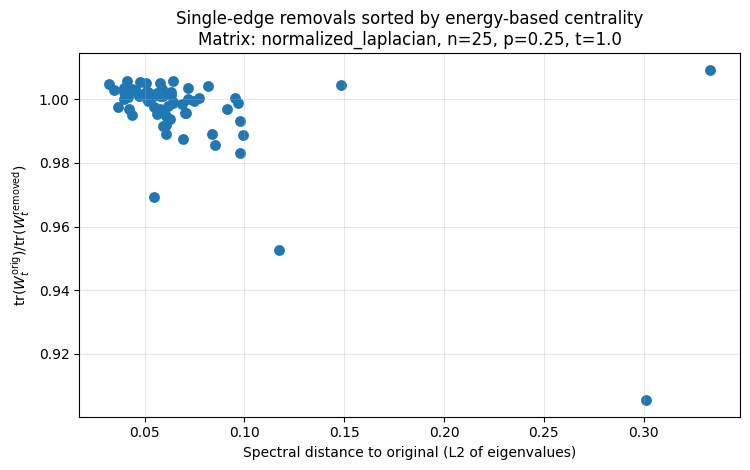

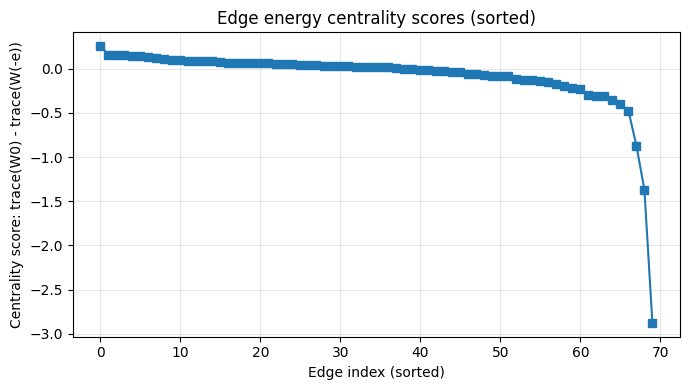

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm, eigvalsh


# -----------------------------
# Finite-time Gramian
# -----------------------------
def finite_time_gramian(A, B, t=1.0):
    """
    W_t = ∫_0^t e^{A τ} B B^T e^{A^T τ} dτ
    via Van Loan block exponential.
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    B = np.asarray(B, dtype=float)

    top = np.hstack([-A, B @ B.T])
    bot = np.hstack([np.zeros((n, n)), A.T])
    M = np.vstack([top, bot])
    T = expm(M * t)
    F22 = T[n:2*n, n:2*n]
    F12 = T[0:n,   n:2*n]
    return F22.T @ F12


# -----------------------------
# Spectral distance between symmetric matrices
# -----------------------------
def spectral_distance_eigs_l2(A, B):
    """
    L2 distance between sorted eigenvalues of two symmetric matrices A, B.
    """
    evA = eigvalsh(A)
    evB = eigvalsh(B)
    return np.linalg.norm(evA - evB, ord=2)


# -----------------------------
# Modular graph matrix functions
# -----------------------------
def adjacency_matrix_np(G, node_list):
    """Adjacency matrix A."""
    return nx.to_numpy_array(G, nodelist=node_list, dtype=float)


def laplacian_matrix_np(G, node_list):
    """Combinatorial Laplacian L = D - A."""
    return nx.laplacian_matrix(G, nodelist=node_list).astype(float).toarray()


def signless_laplacian_matrix_np(G, node_list):
    """Signless Laplacian Q = D + A."""
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    D = np.diag(d)
    return D + A


def normalized_laplacian_matrix_np(G, node_list):
    """
    Normalized Laplacian:
        L_norm = I - D^{-1/2} A D^{-1/2}
    Pure NumPy version to avoid scipy.errstate issues.
    """
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    with np.errstate(divide='ignore'):
        d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    I = np.eye(len(node_list))
    return I - D_inv_sqrt @ A @ D_inv_sqrt


MATRIX_FNS = {
    "adjacency": adjacency_matrix_np,
    "laplacian": laplacian_matrix_np,
    "signless_laplacian": signless_laplacian_matrix_np,
    "normalized_laplacian": normalized_laplacian_matrix_np,
}


def get_matrix_fn(matrix_choice):
    """
    Get the matrix builder function from MATRIX_FNS.
    """
    key = matrix_choice.lower()
    if key not in MATRIX_FNS:
        raise ValueError(
            f"Unknown matrix_choice '{matrix_choice}'. "
            f"Use one of: {list(MATRIX_FNS.keys())}"
        )
    return MATRIX_FNS[key]


# -----------------------------
# Edge centrality over EXISTING edges only
# -----------------------------
def edge_energy_centrality_trace(G, B, t_horizon=1.0, matrix_choice="adjacency"):
    """
    Compute an energy-based edge centrality score for each *existing* edge in G,
    based on the drop in controllability energy (trace(W_t)) when that edge is removed.

    score(u, v) = tr(W_t(full)) - tr(W_t(with edge (u,v) removed))

    Parameters
    ----------
    G : networkx.Graph
        Graph for which to compute edge influence scores.
    B : (n, m) ndarray
        Input matrix for controllability Gramian.
    t_horizon : float
        Time horizon for W_t.
    matrix_choice : str
        One of: "adjacency", "laplacian", "signless_laplacian", "normalized_laplacian".

    Returns
    -------
    scores : dict
        Mapping (u, v) -> edge influence score (float).
    A_full : (n, n) ndarray
        Matrix A used for baseline Gramian computation.
    node_list : list
        Node ordering used for A_full.
    """

    matrix_fn = get_matrix_fn(matrix_choice)
    node_list = list(G.nodes())
    n = len(node_list)

    # Compute baseline Gramian
    A_full = matrix_fn(G, node_list)
    B = np.asarray(B, dtype=float)
    if B.shape[0] != n:
        raise ValueError("B must have shape (n, m) with n = number of nodes.")

    W_full = finite_time_gramian(A_full, B, t=t_horizon)
    tr_full = float(np.trace(W_full))

    # Edge influence scores
    scores = {}
    for (u, v) in G.edges():
        G_mod = G.copy()
        G_mod.remove_edge(u, v)

        A_mod = matrix_fn(G_mod, node_list)
        W_mod = finite_time_gramian(A_mod, B, t=t_horizon)
        tr_mod = float(np.trace(W_mod))

        scores[(u, v)] = tr_full - tr_mod

    return scores, A_full, node_list


# -----------------------------
# One-edge-removal scan, sorted by centrality score
# -----------------------------
def one_edge_removal_scan_sorted_by_centrality(
    G,
    B,
    t_horizon=1.0,
    matrix_choice="adjacency",
    descending=True,
):
    """
    For each existing edge e in G:
      - remove ONLY that edge (from the original graph),
      - compute spectral distance d(A0, A(-e)),
      - compute ratio trace(W0) / trace(W(-e)),

    then sort the resulting points according to the energy-based
    edge centrality score:

        score(u, v) = tr(W0) - tr(W(-e)).

    Parameters
    ----------
    G : networkx.Graph
    B : (n, m) ndarray
    t_horizon : float
    matrix_choice : str
    descending : bool
        If True, sort edges from most influential (largest score)
        to least influential.

    Returns
    -------
    xs : ndarray
        Spectral distances (ordered by centrality score).
    ys : ndarray
        trace(W0) / trace(W(-e)) (same ordering).
    scores_sorted : ndarray
        Sorted edge centrality scores.
    edges_sorted : list
        Corresponding edge list in the same order.
    """
    # Get centrality scores and baseline matrix/data
    scores, A0, node_list = edge_energy_centrality_trace(
        G, B, t_horizon=t_horizon, matrix_choice=matrix_choice
    )

    # Baseline Gramian and trace
    W0 = finite_time_gramian(A0, B, t=t_horizon)
    tr0 = float(np.trace(W0))

    matrix_fn = get_matrix_fn(matrix_choice)

    # Sort edges by score
    sorted_items = sorted(
        scores.items(),
        key=lambda kv: kv[1],
        reverse=descending,
    )

    xs = []
    ys = []
    scores_sorted = []
    edges_sorted = []

    for (edge, score) in sorted_items:
        u, v = edge
        # Remove only this edge (independent of others)
        Gm = G.copy()
        if Gm.has_edge(u, v):
            Gm.remove_edge(u, v)

        A_m = matrix_fn(Gm, node_list)
        W_m = finite_time_gramian(A_m, B, t=t_horizon)
        tr_m = float(np.trace(W_m))

        d_spec = spectral_distance_eigs_l2(A0, A_m)
        ratio = tr0 / (tr_m + 1e-15)  # avoid division by 0

        xs.append(d_spec)
        ys.append(ratio)
        scores_sorted.append(score)
        edges_sorted.append(edge)

    return np.asarray(xs), np.asarray(ys), np.asarray(scores_sorted), edges_sorted


# -----------------------------
# Plot helper
# -----------------------------
def plot_spectral_vs_trace_ratio_sorted(xs, ys, scores, edges, title=None):
    """
    Plot spectral distance vs trace ratio, where the points are
    already ordered according to edge centrality score.
    """
    plt.figure(figsize=(7.6, 4.8))
    plt.scatter(xs, ys, marker='o', linewidth=1.8)
    plt.grid(alpha=0.3)
    plt.xlabel("Spectral distance to original (L2 of eigenvalues)")
    plt.ylabel(r"$\mathrm{tr}(W_t^\mathrm{orig}) / \mathrm{tr}(W_t^\mathrm{removed})$")
    if title is None:
        title = "Single-edge removals (sorted by Gramian trace-drop centrality)"
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # Optional: quick check of how scores relate to index
    # (e.g., monotone decay with index)
    plt.figure(figsize=(7.0, 4.0))
    plt.plot(scores, marker='s')
    plt.grid(alpha=0.3)
    plt.xlabel("Edge index (sorted)")
    plt.ylabel("Centrality score: trace(W0) - trace(W(-e))")
    plt.title("Edge energy centrality scores (sorted)")
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Build a connected ER graph
    n = 25
    p = 0.25
    rng = np.random.default_rng(7)
    G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))

    tries = 0
    while not nx.is_connected(G) and tries < 100:
        G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))
        tries += 1
    if not nx.is_connected(G):
        raise RuntimeError("Failed to sample a connected ER graph.")

    # Choose matrix and Gramian horizon
    matrix_choice = "normalized_laplacian"  # or "laplacian", "signless_laplacian", "normalized_laplacian"
    t_horizon = 1.0

    # Input B (rank-1 all-ones); try B = np.eye(n) for full actuation
    B = np.ones((n, 1))

    # Scan: remove one edge at a time, sorted by Gramian trace-drop centrality
    xs, ys, scores_sorted, edges_sorted = one_edge_removal_scan_sorted_by_centrality(
        G,
        B,
        t_horizon=t_horizon,
        matrix_choice=matrix_choice,
        descending=True,  # largest centrality score first
    )

    # Plot spectral distance vs trace ratio (ordered by centrality)
    plot_spectral_vs_trace_ratio_sorted(
        xs, ys, scores_sorted, edges_sorted,
        title=f"Single-edge removals sorted by energy-based centrality\nMatrix: {matrix_choice}, n={n}, p={p}, t={t_horizon}"
    )


## Conjecture:

Edges - little difference in spectral distance (adjacency) results in little difference in Gramian


Removing edges (ETEC, normalized_laplacian): 100%|██████████████████████████████████████████████████| 61/61 [00:00<00:00, 1388.39it/s]


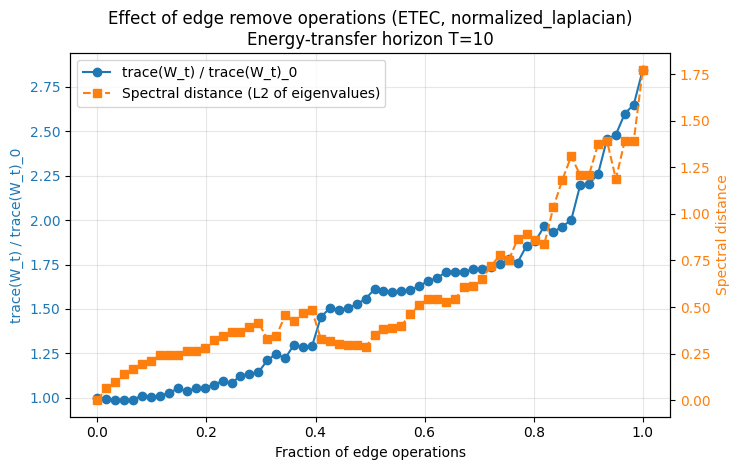

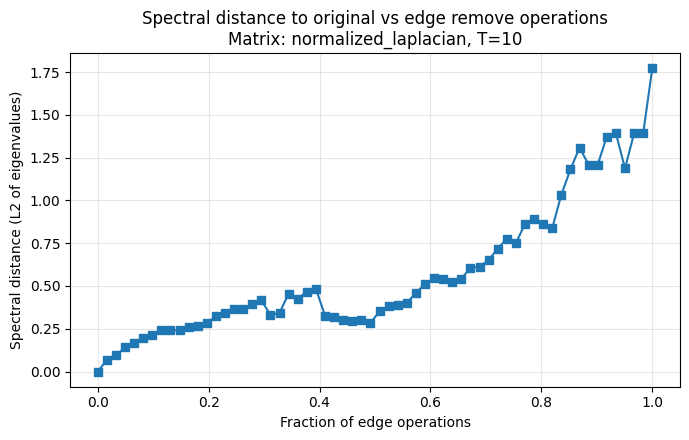

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import expm, eigvalsh
from tqdm import tqdm


# ============================================================
# 1. Finite-time controllability Gramian
# ============================================================
def finite_time_gramian(A, B, t=1.0):
    """
    Finite-time controllability Gramian:
        W_t = ∫_0^t e^{A τ} B B^T e^{A^T τ} dτ
    computed via Van Loan's block matrix exponential.
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    B = np.asarray(B, dtype=float)

    top = np.hstack([-A, B @ B.T])
    bot = np.hstack([np.zeros((n, n)), A.T])
    M = np.vstack([top, bot])
    T = expm(M * t)
    F22 = T[n:2*n, n:2*n]
    F12 = T[0:n,   n:2*n]
    return F22.T @ F12


# ============================================================
# 2. Spectral distance between symmetric matrices
# ============================================================
def spectral_distance_eigs_l2(A, B):
    """
    L2 distance between sorted eigenvalues of two symmetric matrices A, B.
    """
    evA = eigvalsh(A)
    evB = eigvalsh(B)
    return np.linalg.norm(evA - evB, ord=2)


# ============================================================
# 3. Modular graph matrix functions
# ============================================================
def adjacency_matrix_np(G, node_list):
    """Adjacency matrix A."""
    return nx.to_numpy_array(G, nodelist=node_list, dtype=float)


def laplacian_matrix_np(G, node_list):
    """Combinatorial Laplacian L = D - A."""
    return nx.laplacian_matrix(G, nodelist=node_list).astype(float).toarray()


def signless_laplacian_matrix_np(G, node_list):
    """Signless Laplacian Q = D + A."""
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    D = np.diag(d)
    return D + A


def normalized_laplacian_matrix_np(G, node_list):
    """
    Normalized Laplacian:
        L_norm = I - D^{-1/2} A D^{-1/2}
    Implemented with pure NumPy to avoid scipy.errstate issues.
    """
    A = nx.to_numpy_array(G, nodelist=node_list, dtype=float)
    d = A.sum(axis=1)
    with np.errstate(divide="ignore"):
        d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    I = np.eye(len(node_list))
    L_norm = I - D_inv_sqrt @ A @ D_inv_sqrt
    return L_norm


MATRIX_FNS = {
    "adjacency": adjacency_matrix_np,
    "laplacian": laplacian_matrix_np,
    "signless_laplacian": signless_laplacian_matrix_np,
    "normalized_laplacian": normalized_laplacian_matrix_np,
}


def get_matrix_fn(matrix_choice):
    key = matrix_choice.lower()
    if key not in MATRIX_FNS:
        raise ValueError(
            f"Unknown matrix_choice '{matrix_choice}'. "
            f"Use one of {list(MATRIX_FNS.keys())}"
        )
    return MATRIX_FNS[key]


# ============================================================
# 4. Equation (9b) – node influences p_j^(t), q_i^(t)
# ============================================================
def compute_p_q_influences(A, T_score):
    """
    Compute node-to-network and network-to-node influence sequences
    p_j^(t) and q_i^(t) for t = 1,...,T_score as in the
    energy-transfer edge centrality (equation 9b).

    For each node j:
        p_j^(t) = sum_{k=0}^{t-1} || A^k e_j ||_2^2

    For each node i:
        q_i^(t) = sum_{k=0}^{t-1} || (A^T)^k e_i ||_2^2

    Returns
    -------
    P : (T_score, n) array, P[t-1, j] = p_j^(t)
    Q : (T_score, n) array, Q[t-1, i] = q_i^(t)
    """
    A = np.asarray(A, dtype=float)
    n = A.shape[0]
    T_score = int(T_score)

    P = np.zeros((T_score, n), dtype=float)
    Q = np.zeros((T_score, n), dtype=float)

    # p_j^(t): node-to-network (controllability-type)
    for j in range(n):
        v = np.zeros(n, dtype=float)
        v[j] = 1.0  # e_j
        cumulative = 0.0
        for t in range(T_score):
            cumulative += float(v @ v)
            P[t, j] = cumulative
            v = A @ v

    # q_i^(t): network-to-node (observability-type)
    AT = A.T
    for i in range(n):
        v = np.zeros(n, dtype=float)
        v[i] = 1.0  # e_i
        cumulative = 0.0
        for t in range(T_score):
            cumulative += float(v @ v)
            Q[t, i] = cumulative
            v = AT @ v

    return P, Q


# ============================================================
# 5. Energy-transfer edge centrality (equation 9b)
# ============================================================
def energy_transfer_edge_scores_eq9b(G, T_score, matrix_choice="adjacency"):
    """
    Compute energy-transfer edge centrality scores based on equation (9b):

        c_ij^(t) = q_i^(t) * p_j^(t),
        c_ij = (1/T) * sum_{t=1}^T c_ij^(t),

    which leads to the matrix identity:

        C = (1/T) * Q^T @ P,

    where P[t-1, j] = p_j^(t) and Q[t-1, i] = q_i^(t).

    This returns scores for:
      - existing edges (present in G),
      - non-edges (absent in G), if needed.

    For undirected graphs, edge scores are symmetrized as:
        score(u, v) = C[i, j] + C[j, i].

    Parameters
    ----------
    G : networkx.Graph or DiGraph
    T_score : int
        Time horizon used in the centrality definition.
    matrix_choice : str
        "adjacency", "laplacian", "signless_laplacian", or "normalized_laplacian"

    Returns
    -------
    scores_present : dict
        (u, v) -> score for edges in G.
    scores_absent : dict
        (u, v) -> score for unordered non-edges in G.
    C : (n, n) ndarray
        Matrix of c_ij scores for all node pairs (in node_list ordering).
    node_list : list
        Node ordering used throughout.
    """
    matrix_fn = get_matrix_fn(matrix_choice)
    node_list = list(G.nodes())
    n = len(node_list)
    if n == 0:
        return {}, {}, np.zeros((0, 0)), []

    A = matrix_fn(G, node_list)

    # Compute p_j^(t) and q_i^(t)
    P, Q = compute_p_q_influences(A, T_score=T_score)

    # Equation (9b): C = (1/T) * Q^T P
    C = (Q.T @ P) / float(T_score)  # (n x n)

    # Helper: get scalar score(i,j)
    def score_ij(i, j):
        if G.is_directed():
            return float(C[i, j])
        else:
            # symmetric aggregate for undirected networks
            return float(C[i, j] + C[j, i])

    # Build present and absent edge scores
    idx = {node: i for i, node in enumerate(node_list)}
    scores_present = {}
    scores_absent = {}

    nodes = node_list
    # existing edges
    for (u, v) in G.edges():
        i = idx[u]
        j = idx[v]
        scores_present[(u, v)] = score_ij(i, j)

    # non-edges (unordered pairs)
    for i in range(n):
        for j in range(i+1, n):
            u, v = nodes[i], nodes[j]
            if not G.has_edge(u, v) and not (G.is_directed() and G.has_edge(v, u)):
                scores_absent[(u, v)] = score_ij(i, j)

    return scores_present, scores_absent, C, node_list


# ============================================================
# 6. Edge manipulation experiment (remove / add / substitute)
# ============================================================
def edge_manipulation_experiment_etec(
    G,
    B,
    t_horizon=1.0,
    matrix_choice="adjacency",
    T_score=10,
    mode="remove",       # "remove", "add", "substitute"
    max_steps=None
):
    """
    Experiment using energy-transfer edge centrality (equation 9b) as the edge score.

    Steps:
    1) Compute ETEC scores for present and absent edges.
    2) According to 'mode':
        - "remove": remove existing edges ordered by DESCENDING score.
        - "add":    add non-edges ordered by ASCENDING score (lowest first).
        - "substitute":
              at each step:
                * remove a MINIMUM-score existing edge,
                * add a MINIMUM-score non-edge.

       (You can change ordering if you want other behaviors.)

    3) After each step, compute:
        - trace(W_t) for the chosen matrix_choice (using B, t_horizon),
        - spectral distance between current matrix A and original A0.

    Returns
    -------
    results : dict
        mode, matrix_choice, step_indices, frac_steps,
        traces, spectral_distances, edge_ops, A0.
    """
    mode = mode.lower()
    if mode not in {"remove", "add", "substitute"}:
        raise ValueError("mode must be 'remove', 'add', or 'substitute'")

    matrix_fn = get_matrix_fn(matrix_choice)

    # ETEC scores (equation 9b)
    scores_present, scores_absent, C, node_list = energy_transfer_edge_scores_eq9b(
        G,
        T_score=T_score,
        matrix_choice=matrix_choice
    )

    # Baseline matrix and Gramian
    A0 = matrix_fn(G, node_list)
    B = np.asarray(B, dtype=float)
    if B.shape[0] != A0.shape[0]:
        raise ValueError("B must have shape (n, m) with n = number of nodes.")
    W0 = finite_time_gramian(A0, B, t=t_horizon)
    trace0 = float(np.trace(W0))

    traces = [trace0]
    spectral_distances = [0.0]
    step_indices = [0]
    frac_steps = [0.0]
    edge_ops = []  # list of (operation, edge, score)

    # Work on a copy of the graph
    G_curr = G.copy()

    if mode == "remove":
        # Remove edges with highest ETEC first (most influential)
        removal_sequence = sorted(
            scores_present.items(),
            key=lambda kv: kv[1],
            reverse=True
        )
        if max_steps is None:
            max_steps = len(removal_sequence)
        removal_sequence = removal_sequence[:max_steps]

        for k, (edge, score) in tqdm(
            enumerate(removal_sequence, start=1),
            total=len(removal_sequence),
            desc=f"Removing edges (ETEC, {matrix_choice})"
        ):
            u, v = edge
            if G_curr.has_edge(u, v):
                G_curr.remove_edge(u, v)
                edge_ops.append(("remove", edge, score))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k)
            frac_steps.append(k / max_steps)

    elif mode == "add":
        # Add non-edges with MINIMUM ETEC first (as per user specification)
        addition_sequence = sorted(
            scores_absent.items(),
            key=lambda kv: kv[1]  # ascending
        )
        if max_steps is None:
            max_steps = len(addition_sequence)
        addition_sequence = addition_sequence[:max_steps]

        for k, (edge, score) in tqdm(
            enumerate(addition_sequence, start=1),
            total=len(addition_sequence),
            desc=f"Adding edges (ETEC, {matrix_choice})"
        ):
            u, v = edge
            if not G_curr.has_edge(u, v):
                G_curr.add_edge(u, v)
                edge_ops.append(("add", edge, score))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k)
            frac_steps.append(k / max_steps)

    elif mode == "substitute":
        # Remove MINIMUM-score edges and add MINIMUM-score non-edges
        present_sorted = sorted(
            scores_present.items(),
            key=lambda kv: kv[1]  # ascending
        )
        absent_sorted = sorted(
            scores_absent.items(),
            key=lambda kv: kv[1]  # ascending
        )

        if max_steps is None:
            max_steps = min(len(present_sorted), len(absent_sorted))
        max_steps = min(max_steps, len(present_sorted), len(absent_sorted))

        present_sorted = present_sorted[:max_steps]
        absent_sorted = absent_sorted[:max_steps]

        for k in tqdm(
            range(max_steps),
            desc=f"Substituting edges (ETEC, {matrix_choice})"
        ):
            e_rm, s_rm = present_sorted[k]
            e_add, s_add = absent_sorted[k]

            u_rm, v_rm = e_rm
            u_add, v_add = e_add

            if G_curr.has_edge(u_rm, v_rm):
                G_curr.remove_edge(u_rm, v_rm)
                edge_ops.append(("remove", e_rm, s_rm))

            if not G_curr.has_edge(u_add, v_add):
                G_curr.add_edge(u_add, v_add)
                edge_ops.append(("add", e_add, s_add))

            A_curr = matrix_fn(G_curr, node_list)
            W_curr = finite_time_gramian(A_curr, B, t=t_horizon)
            traces.append(float(np.trace(W_curr)))
            d_spec = spectral_distance_eigs_l2(A0, A_curr)
            spectral_distances.append(float(d_spec))

            step_indices.append(k + 1)
            frac_steps.append((k + 1) / max_steps)

    results = {
        "mode": mode,
        "matrix_choice": matrix_choice,
        "T_score": T_score,
        "edge_ops": edge_ops,
        "step_indices": np.array(step_indices),
        "frac_steps": np.array(frac_steps),
        "traces": np.array(traces),
        "spectral_distances": np.array(spectral_distances),
        "A0": A0,
    }
    return results


# ============================================================
# 7. Plotting helper
# ============================================================
def plot_trace_and_spectral(results, normalize_trace=True):
    """
    Plot trace(W_t) and spectral distance vs fraction of edge operations,
    plus a separate spectral-distance-only plot.
    """
    frac = results["frac_steps"]
    traces = results["traces"]
    spectral_distances = results["spectral_distances"]
    mode = results.get("mode", "remove")
    matrix_choice = results.get("matrix_choice", "adjacency")
    T_score = results.get("T_score", None)

    if normalize_trace:
        traces_plot = traces / traces[0]
        trace_label = "trace(W_t) / trace(W_t)_0"
    else:
        traces_plot = traces
        trace_label = "trace(W_t)"

    # Combined plot
    fig, ax1 = plt.subplots(figsize=(7.5, 4.8))

    ax1.plot(
        frac,
        traces_plot,
        marker="o",
        label=trace_label,
    )
    ax1.set_xlabel("Fraction of edge operations")
    ax1.set_ylabel(trace_label, color="C0")
    ax1.tick_params(axis="y", labelcolor="C0")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        frac,
        spectral_distances,
        marker="s",
        linestyle="--",
        label="Spectral distance (L2 of eigenvalues)",
        color="C1",
    )
    ax2.set_ylabel("Spectral distance", color="C1")
    ax2.tick_params(axis="y", labelcolor="C1")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    title = f"Effect of edge {mode} operations (ETEC, {matrix_choice})"
    if T_score is not None:
        title += f"\nEnergy-transfer horizon T={T_score}"
    plt.title(title)
    fig.tight_layout()
    plt.show()

    # Spectral-only plot
    plt.figure(figsize=(7.0, 4.5))
    plt.plot(
        frac,
        spectral_distances,
        marker="s",
        linestyle="-",
    )
    plt.xlabel("Fraction of edge operations")
    plt.ylabel("Spectral distance (L2 of eigenvalues)")
    title2 = f"Spectral distance to original vs edge {mode} operations\nMatrix: {matrix_choice}"
    if T_score is not None:
        title2 += f", T={T_score}"
    plt.title(title2)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 8. Example usage
# ============================================================
if __name__ == "__main__":
    # Example: connected ER graph
    n = 20
    p = 0.3
    t_horizon = 1.0     # time horizon for Gramian
    T_score = 10        # horizon for equation 9b
    seed = 10

    rng = np.random.default_rng(seed)
    G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))

    # Ensure connectivity
    max_tries = 100
    tries = 1
    while not nx.is_connected(G) and tries < max_tries:
        G = nx.fast_gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32 - 1)))
        tries += 1
    if not nx.is_connected(G):
        raise RuntimeError("Could not sample a connected ER graph in max_tries attempts.")

    # Input matrix B: rank-1 all-ones input
    # You can try B = np.eye(n) for full actuation
    B = np.ones((n, 1))

    # Choose matrix representation and mode
    matrix_choice = "normalized_laplacian"        # or "laplacian", "signless_laplacian", "normalized_laplacian"
    mode = "remove"                    # "remove", "add", or "substitute"

    results = edge_manipulation_experiment_etec(
        G,
        B,
        t_horizon=t_horizon,
        matrix_choice=matrix_choice,
        T_score=T_score,
        mode=mode,
        max_steps=None,  # or an integer
    )

    plot_trace_and_spectral(results, normalize_trace=True)
